In [24]:
from __future__ import annotations

import sys
sys.path.append('../')

from tqdm import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch

from pymatgen.core import Structure
from pymatgen.analysis.structure_matcher import StructureMatcher

device = torch.device('cuda:6')

rms_list = []
max_list = []
match_rate_list = []

In [31]:
# Load data
df = pd.read_csv('../data/data_inpaint.csv', keep_default_na=False, na_values=[''])

# Drop rows with float NaN in cif_recon colume for checking before structures completely done.
df = df.dropna(subset=['cif_inpaint'])
print(f"{len(df)} structures left after dropping NaN rows.")

structures_ori = df['cif_ori'].to_list()
structures_recon = df['cif_inpaint'].to_list()

# Convert cif to pymatgen structure
structures_ori = [
    Structure.from_str(s, fmt='cif', frac_tolerance=0, site_tolerance=0) 
    for s in tqdm(structures_ori)
]

structures_recon = [
    Structure.from_str(s, fmt='cif', frac_tolerance=0, site_tolerance=0) 
    for s in tqdm(structures_recon)
]

672 structures left after dropping NaN rows.


100%|██████████| 672/672 [00:04<00:00, 148.45it/s]


In [32]:
# Compute RMSE between the predicted and the target Li positions.
rmss_normed, maxs_normed, rmss, maxs = [], [], [], []
failed_structures = []

for (s_ori, s_recon) in tqdm(list(zip(structures_ori, structures_recon))):
    sm = StructureMatcher(ltol=0.2, stol=0.3)
    match = sm.fit(s_ori, s_recon)
    if match:
        rms_dist_normed, max_dist_normed = sm.get_rms_dist(s_ori, s_recon)
        norm = (s_ori.volume / s_ori.num_sites) ** (1 / 3)
        rms_dist = rms_dist_normed * norm
        max_dist = max_dist_normed * norm
        
        # Consider only Li atoms.
        num_Li = int(s_ori.composition.get_el_amt_dict()['Li'])
        rms_dist = rms_dist*np.sqrt(s_ori.num_sites/num_Li)
        rms_dist_normed = rms_dist/norm
        
        # Save
        rmss_normed.append(rms_dist_normed)
        maxs_normed.append(max_dist_normed)
        rmss.append(rms_dist)
        maxs.append(max_dist)
        
    else:
        failed_structures.append(s_ori)
        rmss_normed.append(np.nan)
        maxs_normed.append(np.nan)
        rmss.append(np.nan)
        maxs.append(np.nan)

100%|██████████| 672/672 [00:11<00:00, 60.98it/s]


In [33]:
# Statistics
print(f"Total number of structures: {len(rmss)} ({len(failed_structures)} failed)")

print(f"Match rate: {(1-len(failed_structures)/len(rmss))*100:.2f}%")
print(f"RMSE: {np.nanmean(rmss):.3f} A")
print(f"Max: {np.nanmean(maxs):.3f} A")
print(f"RMSE_normed: {np.nanmean(rmss_normed):.3f}")
print(f"Max_normed: {np.nanmean(maxs_normed):.3f}")

# Save the results for plotting
rms_list.append(np.nanmean(rmss))
max_list.append(np.nanmean(maxs))
match_rate_list.append((1-len(failed_structures)/len(rmss))*100)

Total number of structures: 672 (243 failed)
Match rate: 63.84%
RMSE: 0.104 A
Max: 0.136 A
RMSE_normed: 0.045
Max_normed: 0.060


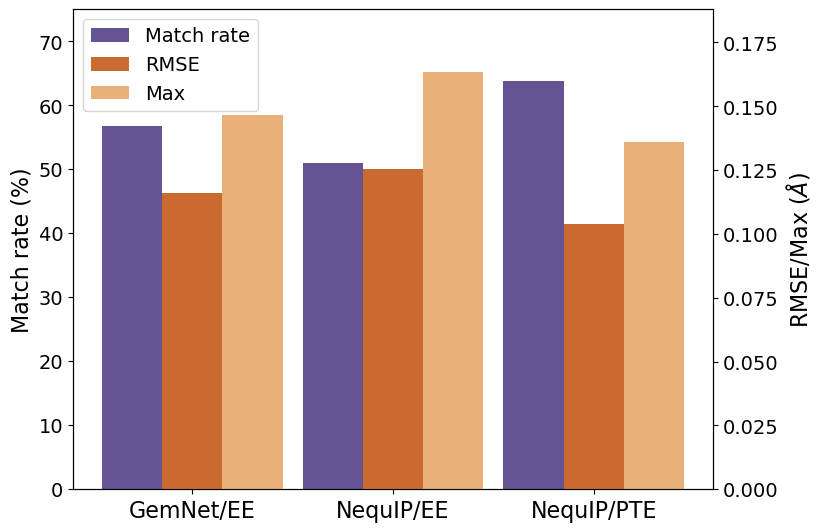

In [102]:
# Plot bar graph
xs = ['GemNet/EE', 'NequIP/EE', 'NequIP/PTE']
labels = ['Match rate', 'RMSE', 'Max']

x1 = np.arange(len(xs))
x2 = [i + 0.3 for i in x1]
x3 = [i + 0.3 for i in x2]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes([0.15,0.15,0.8,0.8])

# Specify color for each bar graph
ax.bar(x1, match_rate_list, width = 0.3, label=labels[0], color='#665393')     #3e5d70 #6fae45
ax2 = ax.twinx()
ax2.bar(x2, rms_list, width = 0.3, label=labels[1], color='#cb6a2f')           #e57259 #4474c4
ax2.bar(x3, max_list, width = 0.3, label=labels[2], color='#e9b079')           #faaf78 #589cd6

ax.set_ylabel('Match rate (%)', fontsize=16)
ax2.set_ylabel('RMSE/Max ($\AA$)', fontsize=16)

# Change x ticks to labels
ax.set_xticks(x2)
ax.set_xticklabels(xs, fontsize=16)

ax.tick_params(axis='y', which='major', labelsize=14)
ax2.tick_params(axis='y', which='major', labelsize=14)

# Change lim
ax.set_ylim([0, 75])
ax2.set_ylim([0, 0.188])


# Show legend together
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=14)


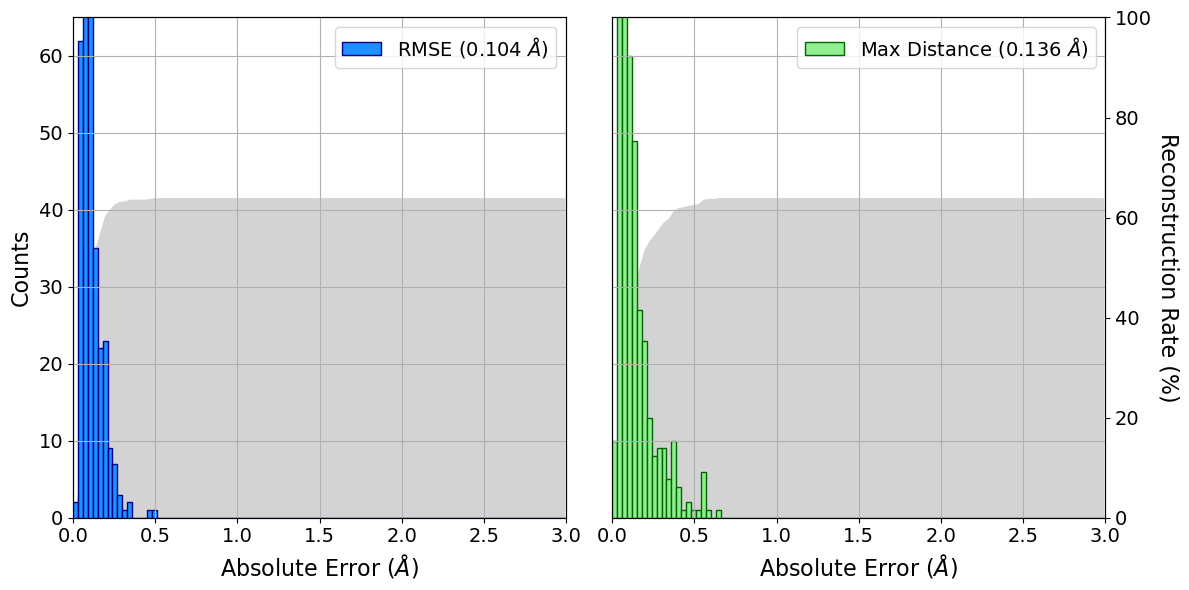

In [17]:
# Compute histogram for rmss and max using numpy

rmss = np.asarray(rmss)
maxs = np.asarray(maxs)

hist_rms, bin_rms = np.histogram(rmss, bins=100, range=(0, 3))
hist_max, bin_max = np.histogram(maxs, bins=100, range=(0, 3))
bin_rms = (bin_rms[:-1] + bin_rms[1:]) / 2
bin_max = (bin_max[:-1] + bin_max[1:]) / 2

percent_rms = []
percent_max = []
for i in range(len(bin_rms)):
    percent_rms.append(np.sum(hist_rms[:i+1])/len(rmss))
    percent_max.append(np.sum(hist_max[:i+1])/len(rmss))

# Plot histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Customize the RMSE plot
ax[0].bar(bin_rms, hist_rms, width=bin_rms[1]-bin_rms[0], color='dodgerblue', edgecolor='darkblue', label=f'RMSE ({np.nanmean(rmss[rmss<3]):.3f} $\AA$)')
ax[0].set_xlabel('Absolute Error ($\AA$)', fontsize=16)
ax[0].set_ylabel('Counts', fontsize=16)
ax[0].grid(True)
ax[0].tick_params(labelsize=14)
ax[0].legend(fontsize=14)

# Add the cumulative percentage
ax2 = ax[0].twinx()
# ax2.plot(bin_rms, percent_rms, color='black', linestyle='--')
ax2.fill_between(bin_rms, np.asarray(percent_rms)*100, color='lightgrey', alpha=1.0)
ax2.tick_params(labelsize=14)
ax2.tick_params(axis='y', length=0)
ax2.set_yticklabels([])

# Customize the Max plot
ax[1].bar(bin_max, hist_max, width=bin_max[1]-bin_max[0], color='lightgreen', edgecolor='darkgreen', label=f'Max Distance ({np.nanmean(maxs[maxs<3]):.3f} $\AA$)')
ax[1].set_xlabel('Absolute Error ($\AA$)', fontsize=16)
ax[1].grid(True)
ax[1].tick_params(labelsize=14)
ax[1].legend(fontsize=14)
ax[1].tick_params(axis='y', length=0)
ax[1].set_yticklabels([])

# Add the cumulative percentage
ax3 = ax[1].twinx()
# ax3.plot(bin_max, percent_max, color='black', linestyle='--')
ax3.fill_between(bin_max, np.asarray(percent_max)*100, color='lightgrey', alpha=1.0)
ax3.set_ylabel('Reconstruction Rate (%)', fontsize=16, rotation=270, labelpad=20)
ax3.set_ylim(0, 1)
ax3.tick_params(labelsize=14)

ax[0].set_ylim(0, 65)
ax[1].set_ylim(0, 65)
ax2.set_ylim(0, 100)
ax3.set_ylim(0, 100)

# Set x-axis limits
ax[0].set_xlim(0, 3)
ax[1].set_xlim(0, 3)

# Adjust the zorder of ax[0] to be on top of ax2
ax[0].set_zorder(ax2.get_zorder() + 1)
ax[0].patch.set_visible(False)  # Hide the 'ax[0]' background
ax[1].set_zorder(ax3.get_zorder() + 1)
ax[1].patch.set_visible(False)  # Hide the 'ax[1]' background

# Adjust the layout
plt.tight_layout()
plt.show()